importing numpy


In [1]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt

In [28]:
ndarr2 = np.array([[1,2,3], [4,5,6], [7,8,9]])
print(ndarr2[0,2])


3


to check data type of an array, use "array_name.dtype" keyword

In [5]:
narr = np.array([1,2,3,4,5])
print(narr.dtype)

int64


In [9]:
narr = np.array([1,2,3,4,5], dtype='U')
print(narr)

['1' '2' '3' '4' '5']


In [18]:
narr = np.array(['0','1','2'], dtype='i')
print(narr)


[0 1 2]


use astype(), when you want to create a copy of an array, but with differet data type, maintain original array and work with duplicate array.

In [23]:
arr = np.array([1,1,1,2,2,3,0])

newarr = arr.astype('bool')
print(newarr)

[ True  True  True  True  True  True False]


"array_name.shape" this method is used to find the dimension of a ndarray. 2-d, 3-d, 4d, etc... returns, a tuple containing number of rows, number of columnns. (row, col).

using .base helps you find if an array is copied or viewed, copied->returns None, viewed->returns original array values.

In [41]:
ndarray = np.array([[1,2,3,4,5],[6,7,8,9,10]])
print(ndarray.shape)

(2, 5)


using array_name.reshape() method will change the dimension of the array to change a 2d-arr to 3-d arr. use -1(ony for 1 dimention) when the dimention values is unknown. using reshape(-1) flattens(1-d's) the array or use flatten().

In [ ]:
ndarray = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
new_ndarry = ndarray.reshape(3,4)
print(new_ndarry)
print(new_ndarry.ndim)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
2


In [69]:
ndarray = np.array([1,2,3,4,5,6,7,8,9,10,11,12])

print(ndarray.flatten())

[ 1  2  3  4  5  6  7  8  9 10 11 12]


iterating through ndarray. 

1. using for loops (same as python lists)
2. using "numpy.nditer(array_name)" -> this helps to iterate the array in depth to the last dimension, usefull for n-dimensionl array, 

In [ ]:
ndarray = np.array([[[1,2,3]],[[4,5,6]],[[7,8,9]]])
for i in np.nditer(ndarray):
    print(i, end=' ')

1 2 3 4 5 6 7 8 9 

-> to change the datatypes while itrerating the array, use "op_dtypes('data_type')".
-> NumPy does not change the data type of the element in-place (where the element is in array) so it needs some other space to perform this action, that extra space is called buffer, and in order to enable it in nditer() we pass flags=['buffered']

In [ ]:
ndarray = np.array([1,2,3,4])

for i in np.nditer(ndarray, flags = ['buffered'], op_dtypes = ['U']):
    print(i)

1
2
3
4


using "enumerate()" function to track index and values.
in numpy -> "np.ndenumerate(array_name)". this returns indexvalues in tuple format #for 1-d array -> "(0,) 1" -> 0 is the index of value 1. 
This format is to keep it handy to return enumerated values for multi dimentional arrays, #eg -> 2-d -> "(0, 0) 1".

In [ ]:
ndarray = np.array([[1,2,3,4],[5,6,7,8]])

for i, x in np.ndenumerate(ndarray):
    print(i, x) 

(0, 0) 1
(0, 1) 2
(0, 2) 3
(0, 3) 4
(1, 0) 5
(1, 1) 6
(1, 2) 7
(1, 3) 8


Using np.concatenate(arr_name) to join two arrays in to 1.
-> using an "axis" paramenter to join multi dimentional arrays.

In [120]:
ndarray = np.array([[1,2,3],[4,5,6],[7,8,9]])
print(np.concatenate(ndarray, axis=0))

[1 2 3 4 5 6 7 8 9]


Boolean masking


In [126]:
ndarray = np.array([1,2,3,4,5,6,7,8,9])
bool_arr = ndarray % 2 != 0
arr = ndarray[bool_arr]
print(arr)
print(bool_arr)

[1 3 5 7 9]
[ True False  True False  True False  True False  True]


In [129]:
ndarray = np.array([[1,2,3],[4,5,6],[7,8,9]])
print(ndarray[ndarray > 5])
bool_arr = ndarray > 5
print(bool_arr)

[6 7 8 9]
[[False False False]
 [False False  True]
 [ True  True  True]]


with the below method, we can use boolean array to remove the evens from the array and print odds in a dupe array.

In [161]:
ndarray = np.array([1,2,3,4,5,6,7,8,9])
bool_arr = ndarray % 2 != 0
arr = ndarray[bool_arr]
print(arr)

[1 3 5 7 9]


stack joining arrays.
axes: axes are positioning indexes for numpy array.

In [148]:
ndarray = np.array([[1,2,3],[4,5,6],[7,8,9]])
ndarray2 = np.array([[10,11,12],[13,14,15],[16,17,18]])
print(ndarray.ndim)
print(np.stack((ndarray, ndarray2), axis=1))

2
[[[ 1  2  3]
  [10 11 12]]

 [[ 4  5  6]
  [13 14 15]]

 [[ 7  8  9]
  [16 17 18]]]


splitting numpy arrays.

using np.array_split(array_name, no.of splits) to split an array into specific parts.
note: if the array has less elements that splits, it automatically adjusts the output, splits array into non equal lengths of splits.

In [158]:
ndarray = np.array([1,2,3,4,5])
res = []
new_arr = np.array_split(ndarray, 3)
print(new_arr[0])
for i in new_arr:
    print(i)

# print(res)

[1 2]
[1 2]
[3 4]
[5]


Searching numpy arrays.

using np.where() and np.searchsorted()

the np.where is used to find only the index of an element satisfying the condition, inside the existing array.

In [164]:
ndarray = np.array([1,2,3,4,5,6,7,8,9])
x = np.where(ndarray == 5)
print(x)

(array([4]),)


np.searchSorted(array_name, value) is used to find only the index of an element being inserted into the array, to keep the array sorted.(eg: bisect in python) 
-> Works only on sorted array.
->using params like (side = 'right') will return the index from right to insert the element.
->(side = 'left')-> by default.
->can find insert index for multiple elements by passing a list containing the values.

In [159]:
ndarray = np.array([1,2,3,4,5,6])
print(np.searchsorted(ndarray, 3))


2


In [160]:
ndarray = np.array([1,3,5])
print(np.searchsorted(ndarray, [2,4,6]))

[1 2 3]


Random module.

//from numpy import random//

This ia a module in numpy to generate random numbers randomly, or by setting probability percent to it.


In [13]:
x = random.randint(1, 10, size=(3,3))
y = random.choice([3,4,5,6], size=(3,3))
print(y)
print(x)

[[6 6 5]
 [6 5 4]
 [3 3 5]]
[[1 6 6]
 [1 2 1]
 [2 5 5]]


Data distribution using numpy.

What is Data Distribution?
Data Distribution is a list of all possible values, and how often each value occurs.

Such lists are important when working with statistics and data science.

The random module offer methods that returns randomly generated data distributions.

....Random Probability parameter....

setting probability for each choice value.
-> paramenter =>  p = [probability values]
-> The sum of all probability numbersmust be 1.

In [33]:
z = random.choice([2,3,4,5], p = [0.1, 0.2, 0.3, 0.4], size=(100))
print(z)

[5 5 5 4 4 5 2 5 5 5 4 3 4 5 5 5 3 4 2 5 5 5 5 3 5 5 3 4 2 5 5 4 5 3 3 4 3
 4 2 5 4 4 4 5 2 4 4 5 4 5 4 5 3 4 4 4 5 5 4 4 5 5 4 5 4 5 5 4 3 3 3 2 4 4
 4 5 3 3 3 2 4 3 5 2 4 5 5 4 4 5 5 3 3 5 4 2 2 5 5 5]


.........Random Permutations parameter......

permutation is a different arrangement of the elements of an array.
-> two methods => shuffle() and permutation().
-> shuffle() permutes the original array.
-> permutation() permutes the copy of an array maintaining originality.

In [57]:
x = np.array([1,2,3])
print(random.shuffle(x)) # prints None
print(x)

y = np.array([4,5,6])
print(random.permutation(y))
print(y) # maintains original array

None
[2 1 3]
[6 4 5]
[4 5 6]


importing matplotlib.pyplot as plt.

drawing a line in agraph.

C:\Users\moham\AppData\Local\Temp\ipykernel_30372\3174399694.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "o-.r" (-> color='r'). The keyword argument will take precedence.
  plt.plot(y_points,'o-.r', color='m')


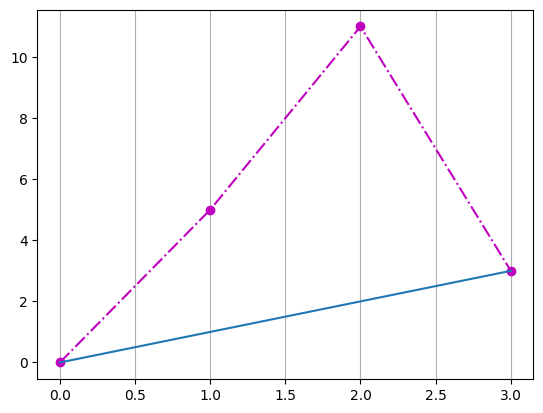

In [96]:
x_points = np.array([0,1, 2, 3])
y_points = np.array([0,5,11, 3])

plt.plot(y_points,'o-.r', color='m')
plt.plot(x_points)
plt.grid(axis = 'x')
# plt.plot(x_points, y_points,color='red', marker = 'o', linestyle = 'dashed')
# plt.xlabel("X-axis")
# plt.ylabel("Y-axis")
plt.show()

subplots


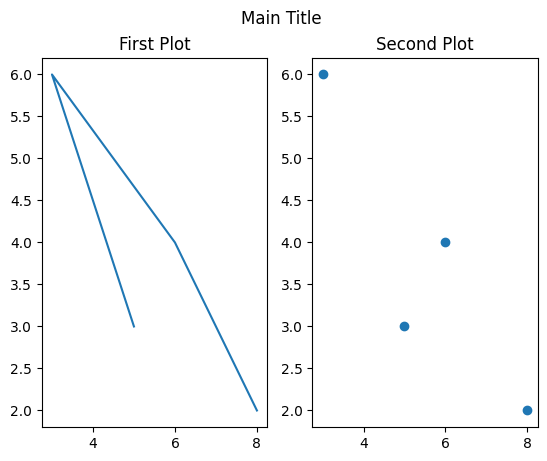

In [105]:
x_plots = np.array([5,3,6,8])
y_plots = np.array([3,6,4,2])

plt.subplot(1,2,1)
plt.plot(x_plots, y_plots)
plt.title("First Plot")

plt.subplot(1,2,2)
plt.scatter(x_plots, y_plots)
plt.title("Second Plot")

plt.suptitle("Main Title")
plt.show()

bars in matplotlib

<BarContainer object of 4 artists>

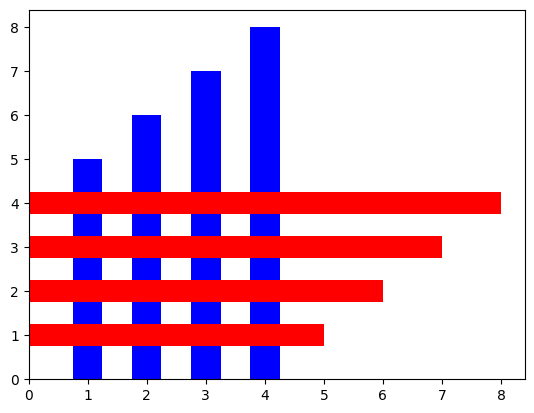

In [109]:
x = np.array([1,2,3,4])
y = np.array([5,6,7,8])

plt.bar(x, y, color = 'blue', width = 0.5)
plt.barh(x, y, color = 'red', height = 0.5)

matplotlib histograms.


[5 5 4 2 4]
[ 4.   5.2  6.4  7.6  8.8 10. ]


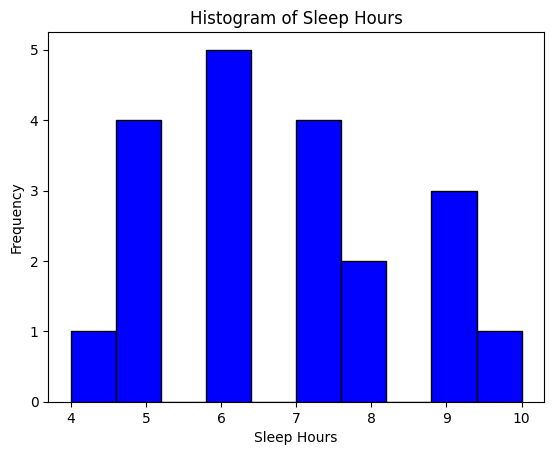

In [3]:
sleep_hours = np.array([5,6,7,8,9,10,4,5,6,7,5,8,9,7,6,5,6,7,6,9])

hist, bin = np.histogram(sleep_hours, bins=5)
print(hist)
print(bin)

plt.hist(sleep_hours, bins=10, color='blue', edgecolor='black')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')
plt.title('Histogram of Sleep Hours')
plt.show()

piechart in matplotlib.


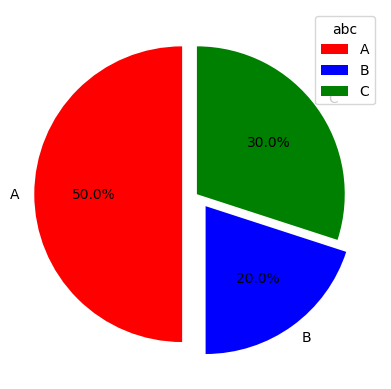

In [21]:
ndarray = np.array([50,20,30])
pie = plt.pie(ndarray, labels = ['A', 'B', 'C'], colors=['red', 'blue', 'green'], explode = [0.1, 0.1, 0],  startangle=90, autopct='%1.1f%%')
plt.legend(title = 'abc')
plt.show()

Seaborn:

using seaborn module: (Seaborn is a library that uses Matplotlib underneath to plot graphs. It will be used to visualize random distributions.)
-> importing seaborn, (import seaborn as sns)